In [17]:
import cv2
import time
from insightface.app import FaceAnalysis
from matplotlib import pyplot as plt

app = FaceAnalysis()
어떤 모델 쓸지 설정
app.prepare()
-> 실제 모델 다운로드, ONNX 모델 로드, detector 초기화, recognition 초기화

In [18]:
app = FaceAnalysis(
    providers=['CPUExecutionProvider']
)

app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112]

### test.jpg 이미지 읽기

In [99]:
img = cv2.imread("../images/test16.jpg")

 ### detection 시간 측정
 - 얼굴 검출, landmark 추출, embedding 생성 얼굴 개수 측정
 - detection 시간 측정

In [100]:
start = time.perf_counter()
faces = app.get(img)
end = time.perf_counter()

face.bbox -> [x1,y1,x2,y2] 형태의 얼굴 좌표 반환
- 왼쪽 위(100,50)
- 오른쪽 아래(300,280)
박스라는 의미



In [101]:
for idx, face in enumerate(faces):

    print(f"\n========== FACE {idx+1} ==========")

    # bbox
    bbox = face.bbox.astype(int)
    print("BBOX :", bbox)

    # landmark
    print("랜드마크 :")
    print(face.kps)

    # embedding
    print("임베딩 형태 :", face.embedding.shape)

    # embedding 일부만 출력
    print("Embedding Sample :")
    print(face.embedding[:10])

    # bbox 좌표
    x1, y1, x2, y2 = bbox

    # -----------------------------
    # bbox 그리기
    # -----------------------------
    cv2.rectangle(
        img,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        2
    )

    # -----------------------------
    # landmark 점 찍기
    # -----------------------------
    for kp in face.kps:

        x, y = map(int, kp)

        cv2.circle(
            img,
            (x,y),
            3,
            (255,0,0),
            -1
        )


========== FACE 1 ==========
BBOX : [ 32 102 163 260]
랜드마크 :
[[ 79.98586  176.21136 ]
 [138.6484   178.74881 ]
 [114.874504 205.86984 ]
 [ 85.99793  230.89842 ]
 [127.57531  232.44872 ]]
임베딩 형태 : (512,)
Embedding Sample :
[-0.3554782  -0.44501847  1.3709674   1.0732507   2.3199046   1.5507059
  0.11492544  1.4778037  -0.9192312   1.0685365 ]


얼굴 주변에 초록색 사각형 생성

### 결과 출력

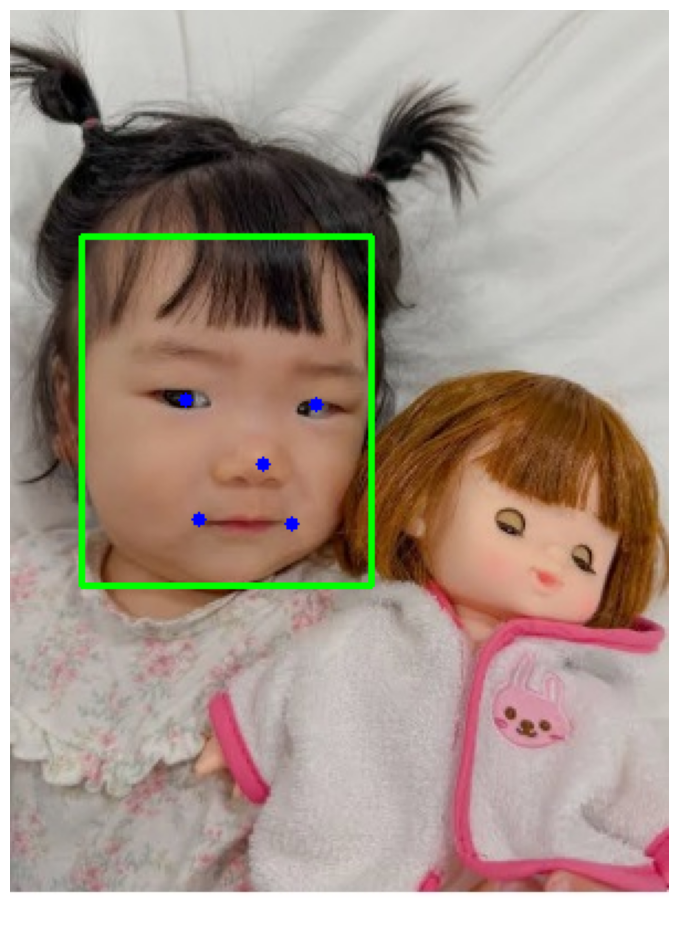

In [102]:
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,12))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

### 검출된 얼굴 수 및 소요 시간 결과 출력

In [103]:
print("검출된 얼굴 수:", len(faces))
latency_ms = (end-start) * 1000
latency_sec = latency_ms / 1000
print(f"걸린 시간      : {latency_ms:.2f} ms ({latency_sec:.2f} sec)")

검출된 얼굴 수: 1
걸린 시간      : 554.06 ms (0.55 sec)
